# Трансферное обучение для классификации джетов в физике высоких энергий: GNN

В качестве основной модели используется графовая нейронная сеть (GNN),
работающая с графовым представлением конституентов джета.


### Этап 2: Transfer Learning с использованием GNN

Современные state-of-the-art модели для джет-теггинга используют архитектуры графовых нейронных сетей (GNN). Поэтому следующая цель - построить Teacher- и Student-модели на основе GNN и реализовать перенос знаний аналогично тому, как это было сделано для FCNN.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.optim as optim
from helper import *
from preprocess import *
from torch_geometric.loader import DataLoader
from visualize import *

sns.set_theme()
plt.style.use("seaborn-v0_8")

# import warnings
# warnings.filterwarnings('ignore')

In [2]:
# Initialize some global hyperparameters

K = 16  # number of neighbors for the KNN
NE = 15  # number of epochs
LR = 3e-4  # learning rate
WEIGHT_DECAY = 1e-5  # weight decay for L2 regularization
BATCH_SZ = 384  # batch size
MAX_ITEMS = 250000  # maximum number of elements to consider (input size)
MAX_CONSTITS = 80  # maximum number of constituent elements per jet: 80
REDUCED_CONSTITS = 80  # number of constituent elements for the Student network to consider: 40
NOISE_STD = 1e4  # noise standard deviation for the diffusion
ALPHA = 0.5  # alpha parameter for knowledge transfer: 0.8
TEMP = 2.0  # temperature parameter for knowledge transfer: 2.0

Аналогично первому ноутбуку, начнем с загрузки данных и предобработки. Однако теперь мы работаем с графами, поэтому этапы предобработки будут существенно отличаться.

In [3]:
cons_data, cons_labels, cons_weights, cons_features = get_data(
    "./data/train.h5",
    attribute="constituents",
    max_items=MAX_ITEMS,
)

print("---------- Constituent-level data ----------------", "\n")
print("Data shape [input_size, num_constituents, num_features]:", cons_data.shape, "\n")
print("Feature names:", cons_features)
print("Feature names (human-readable):", [human_feature(f) for f in cons_features])

---------- Constituent-level data ---------------- 

Data shape [input_size, num_constituents, num_features]: (250000, 200, 4) 

Feature names: ['fjet_clus_pt' 'fjet_clus_eta' 'fjet_clus_phi' 'fjet_clus_E']
Feature names (human-readable): ['constituent transverse momentum', 'constituent pseudo-rapidity', 'constituent azimuthal angle', 'constituent energy']


Предобработку будем выполнять по тем же шагам, что и для FCNN.

In [4]:
pre_cons_data, pre_cons_features = constituent_preprocess(
    cons_data, cons_features, max_constits=MAX_CONSTITS
)

print("Preprocessed constituent data shape:", pre_cons_data.shape)
print("Preprocessed features:", pre_cons_features)

/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:165: RuntimeWarning: divide by zero encountered in log
  log_pt = np.log(pt)
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:166: RuntimeWarning: divide by zero encountered in log
  log_energy = np.log(energy)
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:173: RuntimeWarning: divide by zero encountered in log
  lognorm_pt = np.log(pt / sum_pt[:,np.newaxis])
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:174: RuntimeWarning: divide by zero encountered in log
  lognorm_energy = np.log(energy / sum_energy[:,np.newaxis])


Preprocessed constituent data shape: (250000, 80, 7)
Preprocessed features: ['delta_eta' 'delta_phi' 'log_pt' 'log_E' 'lognorm_pt' 'lognorm_E' 'R']


Для реализации GNN необходимо построить графы из данных. Для этого используется алгоритм *k-ближайших соседей (kNN)*. По возможности процесс построения графов выполняется на GPU для ускорения вычислений.


In [5]:
# Check for CUDA, then default to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

graphs = prepare_graphs(
    pre_cons_data, cons_labels, k=K, weights=cons_weights, device=device, batch_size=BATCH_SZ
)

Device: cuda


/users/jmduchar/anaconda/research/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|█████████████████████████████████████████| 652/652 [14:32<00:00,  1.34s/it]


In [6]:
# visualize_graph(graphs[100], x_axis='fjet_clus_phi', y_axis='fjet_clus_eta')

#### Построение Teacher GNN

Построим Teacher-модель на основе GNN и обучим ее на данных высокого качества (high-resolution).


In [7]:
from model import run_model, train_with_distillation


def training_loop(
    model, device, graphs, plot_confusion=False, teacher_model=None, alpha=ALPHA, temp=TEMP
):
    """
    Run the whole training loop on the model given data, labels, and weights

    References a lot of global parameters
    """
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss(reduction="none")
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Data preparation
    train_set, val_set, test_set = split_graphs(graphs, 0.7, 0.15)

    train_loader = DataLoader(train_set, batch_size=BATCH_SZ, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SZ, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SZ, shuffle=True)

    loss_list, acc_list = [], []
    val_loss_list, val_acc_list = [], []

    t0 = time.time()
    for epoch in range(1, NE + 1):
        # training -- with knowledge distillation
        if teacher_model:
            loss, acc = train_with_distillation(
                model,
                teacher_model,
                "gnn",
                train_loader,
                criterion,
                optimizer,
                device,
                alpha=alpha,
                temperature=temp,
            )

        # training -- without knowledge distillation
        else:
            loss, acc = run_model(
                model, "gnn", device, train_loader, criterion, optimizer=optimizer, train=True
            )

        loss_list.append(loss)
        acc_list.append(acc)

        # validation
        val_loss, val_acc, _, _ = run_model(
            model, "gnn", device, val_loader, criterion, train=False
        )
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        if epoch % 5 == 0:
            print(
                f"E {epoch:02d} -- Train loss: {loss:.3f} -- Train acc: {acc:.3f} -- "
                + f"Val loss: {val_loss:.3f} -- Val acc: {val_acc:.3f} -- t elapsed: {time_elapsed(t0,time.time())} mins"
            )

    # Testing on unseen data...
    test_loss, test_acc, fpr, tpr = run_model(
        model,
        "gnn",
        device,
        test_loader,
        criterion,
        train=False,
    )

    # And finally plot the confusion matrix if desired
    if plot_confusion:
        true = []
        pred = []
        for d, l, w in test_set:
            d = d.unsqueeze(0)
            true.append(l.item())
            p = np.argmax(model(d.to(device)).cpu().detach().numpy())
            pred.append(p)

        plot_confusion_matrices(true, pred, "")

    return loss_list, acc_list, val_loss_list, val_acc_list, test_loss, test_acc, fpr, tpr

In [8]:
from model import JetGNN
from preprocess import split_graphs

# initialize model
teacher_gnn = JetGNN().to(device)

# Train and test the model
unpackable1 = training_loop(teacher_gnn, device, graphs)

# Unpack results
(
    teach_trainloss,
    teach_trainacc,
    teach_valloss,
    teach_valacc,
    teach_testloss,
    teach_testacc,
    fpr_teacher,
    tpr_teacher,
) = unpackable1

E 05 -- Train loss: 0.355 -- Train acc: 0.845 -- Val loss: 0.361 -- Val acc: 0.844 -- t elapsed: 8.69 mins
E 10 -- Train loss: 0.319 -- Train acc: 0.863 -- Val loss: 0.364 -- Val acc: 0.857 -- t elapsed: 17.33 mins
E 15 -- Train loss: 0.292 -- Train acc: 0.872 -- Val loss: 0.361 -- Val acc: 0.843 -- t elapsed: 25.98 mins


Teacher GNN trained on high-quality data


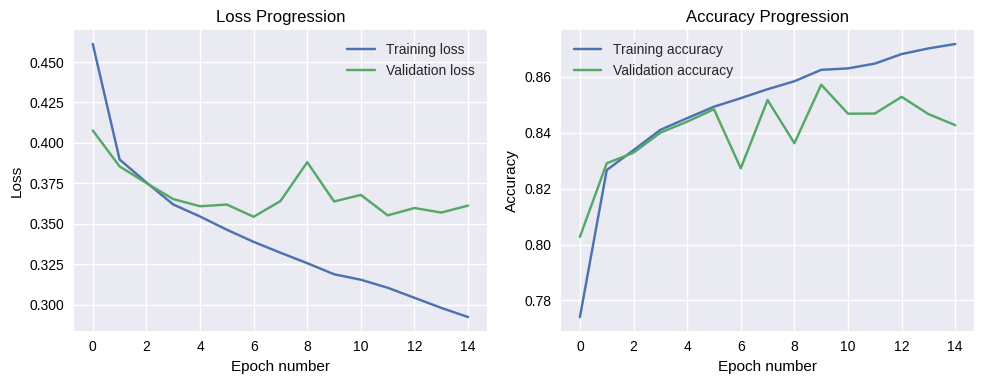

Final test loss: 0.3582	 Final test acc: 0.8459


In [9]:
print("Teacher GNN trained on high-quality data")

plot_loss_and_accuracy(
    teach_trainloss,
    teach_valloss,
    teach_trainacc,
    teach_valacc,
    # transparent=True,
    # save_path="./teacher_fcnn.png",
)

print(f"Final test loss: {teach_testloss:.4f}\t Final test acc: {teach_testacc:.4f}")

#### Диффузия данных

Далее добавляем шум (diffusion) к входным данным по признаку энергии, затем дополняем данные нулями до исходного числа конституентов и заново строим графы.



In [10]:
from helper import diffuse

diffused_cons_data = diffuse(
    cons_data,
    cons_features,
    noise_std=NOISE_STD,
    apply_features=["fjet_clus_E", "fjet_clus_pt"],
)

diff_pre_cons_data, _ = constituent_preprocess(
    diffused_cons_data, cons_features, max_constits=REDUCED_CONSTITS
)
padded_data = add_constits(diff_pre_cons_data, target_shape=MAX_CONSTITS)

reduced_graphs = prepare_graphs(
    padded_data, cons_labels, k=K, weights=cons_weights, device=device, batch_size=BATCH_SZ
)

/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:165: RuntimeWarning: divide by zero encountered in log
  log_pt = np.log(pt)
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:165: RuntimeWarning: invalid value encountered in log
  log_pt = np.log(pt)
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:166: RuntimeWarning: divide by zero encountered in log
  log_energy = np.log(energy)
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:166: RuntimeWarning: invalid value encountered in log
  log_energy = np.log(energy)
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:173: RuntimeWarning: divide by zero encountered in log
  lognorm_pt = np.log(pt / sum_pt[:,np.newaxis])
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:173: RuntimeWarning: invalid value encountered in log
  lognorm_pt = np.log(pt / sum_pt[:,np.newaxis])
/oscar/data/jpober/jmduchar/DL-Final-Project/preprocess.py:174: RuntimeWarning: divide by zero encountered in log
  l

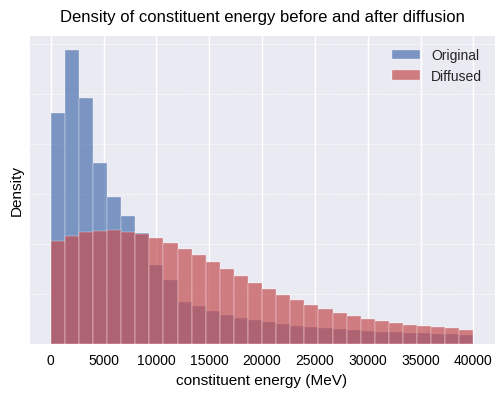

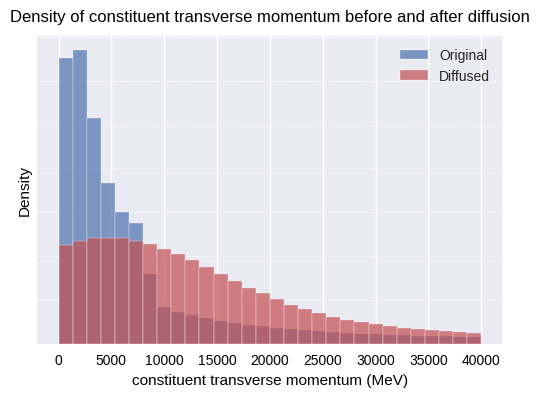

In [11]:
plot_diffused_histogram(
    cons_data,
    diffused_cons_data,
    cons_features,
    plot_feature="fjet_clus_E",
    xrange=[0, 4e4],
    transparent=False,
    save_path="./gnn_diffusion_E.png",
)

plot_diffused_histogram(
    cons_data,
    diffused_cons_data,
    cons_features,
    plot_feature="fjet_clus_pt",
    xrange=[0, 4e4],
    transparent=False,
    save_path="./gnn_diffusion_pt.png",
)

### Student-модель без дистилляции знаний

In [12]:
# initialize model
student_no_distill = JetGNN().to(device)

# Run the training loop
unpackable2 = training_loop(student_no_distill, device, reduced_graphs)

# Unpack the results
(
    stu_trainloss,
    stu_trainacc,
    stu_valloss,
    stu_valacc,
    stu_testloss,
    stu_testacc,
    fpr_student,
    tpr_student,
) = unpackable2

E 05 -- Train loss: 0.476 -- Train acc: 0.748 -- Val loss: 0.480 -- Val acc: 0.751 -- t elapsed: 8.81 mins
E 10 -- Train loss: 0.452 -- Train acc: 0.765 -- Val loss: 0.472 -- Val acc: 0.760 -- t elapsed: 17.55 mins
E 15 -- Train loss: 0.431 -- Train acc: 0.776 -- Val loss: 0.473 -- Val acc: 0.758 -- t elapsed: 26.28 mins


Student GNN trained on low-quality data without knowledge distillation


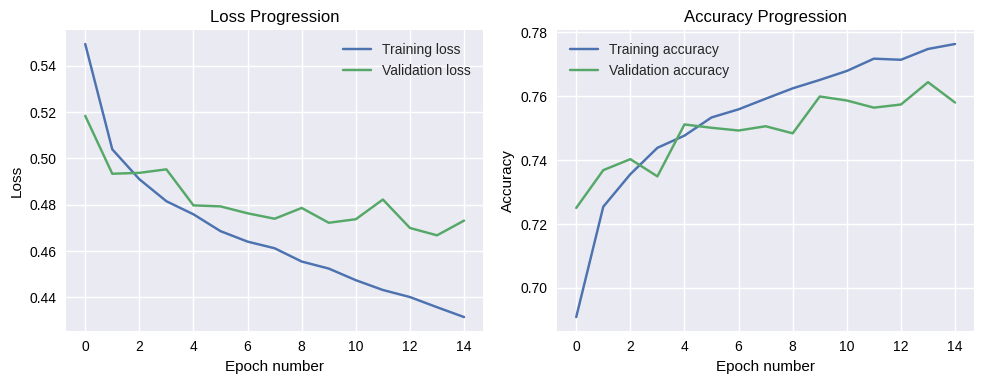

Final test loss: 0.4791	 Final test acc: 0.7544


In [13]:
print("Student GNN trained on low-quality data without knowledge distillation")

plot_loss_and_accuracy(
    stu_trainloss,
    stu_valloss,
    stu_trainacc,
    stu_valacc,
    # transparent=True,
    # save_path="./student_fcnn_nodistill.png",
)
print(f"Final test loss: {stu_testloss:.4f}\t Final test acc: {stu_testacc:.4f}")

### Перенос знаний от Teacher к Student GNN


In [14]:
# initialize model
student_gnn = JetGNN().to(device)

# run the training loop
unpackable3 = training_loop(student_gnn, device, reduced_graphs, teacher_model=teacher_gnn)

# unpack results
(
    dist_trainloss,
    dist_trainacc,
    dist_valloss,
    dist_valacc,
    dist_testloss,
    dist_testacc,
    fpr_distill,
    tpr_distill,
) = unpackable3

/users/jmduchar/anaconda/research/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


E 05 -- Train loss: 0.394 -- Train acc: 0.638 -- Val loss: 0.640 -- Val acc: 0.626 -- t elapsed: 10.62 mins
E 10 -- Train loss: 0.386 -- Train acc: 0.646 -- Val loss: 0.597 -- Val acc: 0.646 -- t elapsed: 21.25 mins
E 15 -- Train loss: 0.381 -- Train acc: 0.650 -- Val loss: 0.602 -- Val acc: 0.640 -- t elapsed: 31.88 mins


Объединим все результаты в один график ROC-кривых.

Student GNN trained on low-quality data with knowledge distillation


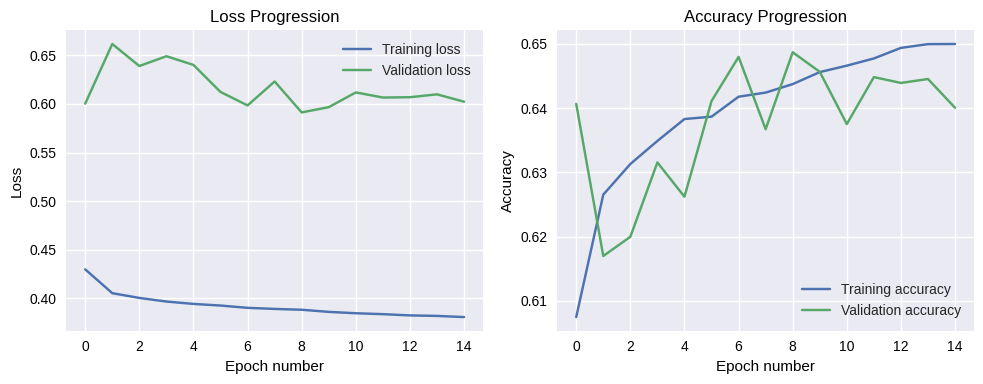

Final test loss: 0.6045	 Final test acc: 0.6447


In [15]:
print("Student GNN trained on low-quality data with knowledge distillation")

plot_loss_and_accuracy(
    dist_trainloss,
    dist_valloss,
    dist_trainacc,
    dist_valacc,
    # transparent=True,
    # save_path="./student_fcnn_withdistill.png",
)

print(f"Final test loss: {dist_testloss:.4f}\t Final test acc: {dist_testacc:.4f}")

In [18]:
# Note: good performance and speed with NVIDIA TITAN RTX

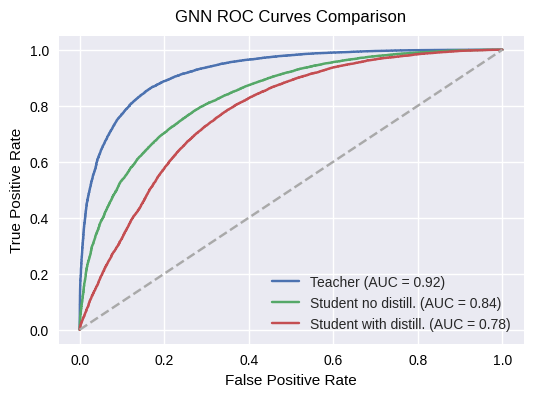

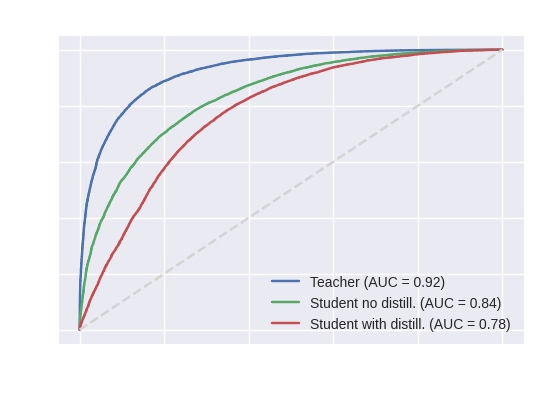

In [16]:
plot_roc(
    fpr_teacher,
    tpr_teacher,
    fpr_student,
    tpr_student,
    fpr_distill,
    tpr_distill,
    model_name="GNN",
    transparent=False,
    save_path="./GNN_ROC_undersampling.png",
)

plot_roc(
    fpr_teacher,
    tpr_teacher,
    fpr_student,
    tpr_student,
    fpr_distill,
    tpr_distill,
    model_name="GNN",
    transparent=True,
    save_path="./GNN_ROC_undersampling_transparent.png",
)